<a href="https://colab.research.google.com/github/domenica-arpi/CNN-VGG16---Tomatoes-Dataset/blob/main/CNN_VGG16_Tomatoes_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de tomates mediante CNN VGG16

Este notebook implementa una red neuronal convolucional basada en la arquitectura VGG16 para clasificar imágenes de tomates en diferentes categorías.  
Se aplica aprendizaje por transferencia utilizando pesos preentrenados en ImageNet y se entrena una nueva cabeza clasificadora adaptada al dataset de tomates.

Dataset utilizado: Tomatoes Dataset - Kaggle  
Arquitectura utilizada: VGG16  
Herramientas: Python, Google Colab, TensorFlow, Keras, NumPy, Matplotlib, Seaborn y Scikit-learn.

In [ ]:
# ==========================================
# ETAPA 1.1 - VERIFICAR GPU EN GOOGLE COLAB
# ==========================================

import tensorflow as tf

print("Versión de TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detectada y lista para usar 🚀")
    print(gpus)
else:
    print("GPU no detectada. Revisa: Entorno de ejecución > Cambiar tipo de entorno > T4 GPU")

Versión de TensorFlow: 2.20.0
GPU detectada y lista para usar 🚀
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ==========================================
# ETAPA 1.2 - INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ==========================================

!pip install -q kagglehub

import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [ ]:
# ==========================================
# ETAPA 1.3 - CONFIGURACIÓN GENERAL
# ==========================================

SEED = 123
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_HEAD = 25
EPOCHS_FINE = 15

LR_HEAD = 1e-4
LR_FINE = 1e-5

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuración del proyecto")
print("Tamaño de imagen:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Épocas entrenamiento inicial:", EPOCHS_HEAD)
print("Épocas fine-tuning:", EPOCHS_FINE)
print("Learning rate inicial:", LR_HEAD)
print("Learning rate fine-tuning:", LR_FINE)

Configuración del proyecto
Tamaño de imagen: (224, 224)
Batch size: 32
Épocas entrenamiento inicial: 25
Épocas fine-tuning: 15
Learning rate inicial: 0.0001
Learning rate fine-tuning: 1e-05


In [ ]:
# ==========================================
# ETAPA 2.1 - DESCARGAR DATASET DESDE KAGGLE
# ==========================================

path = kagglehub.dataset_download("enalis/tomatoes-dataset")

print("Dataset descargado correctamente.")
print("Ruta principal del dataset:")
print(path)

100%|██████████| 93.7M/93.7M [00:00<00:00, 138MB/s]

Extracting files...


Dataset descargado correctamente.
Ruta principal del dataset:
/root/.cache/kagglehub/datasets/enalis/tomatoes-dataset/versions/4


In [ ]:
# ==========================================
# ETAPA 2.2 - DEFINIR RUTAS DEL DATASET
# ==========================================

EXPECTED_ROOT = os.path.join(path, "content", "ieee-mbl-cls")

TRAIN_PATH = os.path.join(EXPECTED_ROOT, "train")
VAL_PATH = os.path.join(EXPECTED_ROOT, "val")
TEST_PATH = os.path.join(EXPECTED_ROOT, "test")

# Si las rutas esperadas no existen, se busca automáticamente una carpeta que tenga train y val
if not os.path.exists(TRAIN_PATH) or not os.path.exists(VAL_PATH):
    print("No se encontró la ruta esperada. Buscando estructura del dataset...")

    posibles_raices = []

    for root, dirs, files in os.walk(path):
        dirs_lower = [d.lower() for d in dirs]

        if "train" in dirs_lower and ("val" in dirs_lower or "valid" in dirs_lower or "validation" in dirs_lower):
            posibles_raices.append(root)

    if len(posibles_raices) == 0:
        raise FileNotFoundError("No se encontró una estructura con carpetas train y val.")

    DATA_ROOT = posibles_raices[0]
    TRAIN_PATH = os.path.join(DATA_ROOT, "train")

    if os.path.exists(os.path.join(DATA_ROOT, "val")):
        VAL_PATH = os.path.join(DATA_ROOT, "val")
    elif os.path.exists(os.path.join(DATA_ROOT, "valid")):
        VAL_PATH = os.path.join(DATA_ROOT, "valid")
    else:
        VAL_PATH = os.path.join(DATA_ROOT, "validation")

    TEST_PATH = os.path.join(DATA_ROOT, "test")

print("Ruta de entrenamiento:")
print(TRAIN_PATH)

print("\nRuta de validación:")
print(VAL_PATH)

if os.path.exists(TEST_PATH):
    print("\nRuta de prueba:")
    print(TEST_PATH)
else:
    print("\nNo existe carpeta test. Se dividirá la validación para crear un conjunto de prueba.")

Ruta de entrenamiento:
/root/.cache/kagglehub/datasets/enalis/tomatoes-dataset/versions/4/content/ieee-mbl-cls/train

Ruta de validación:
/root/.cache/kagglehub/datasets/enalis/tomatoes-dataset/versions/4/content/ieee-mbl-cls/val

No existe carpeta test. Se dividirá la validación para crear un conjunto de prueba.


In [ ]:
# ==========================================
# ETAPA 2.3 - ANALIZAR CLASES Y CANTIDADES
# ==========================================

def contar_imagenes_por_clase(ruta):
    extensiones_validas = (".jpg", ".jpeg", ".png", ".bmp", ".gif")
    datos = []

    for clase in sorted(os.listdir(ruta)):
        ruta_clase = os.path.join(ruta, clase)

        if os.path.isdir(ruta_clase):
            cantidad = len([
                archivo for archivo in os.listdir(ruta_clase)
                if archivo.lower().endswith(extensiones_validas)
            ])

            datos.append({
                "clase": clase,
                "cantidad": cantidad
            })

    return pd.DataFrame(datos)

df_train = contar_imagenes_por_clase(TRAIN_PATH)
df_val = contar_imagenes_por_clase(VAL_PATH)

print("Distribución del conjunto de entrenamiento:")
display(df_train)

print("\nDistribución del conjunto de validación:")
display(df_val)

print("\nTotal entrenamiento:", df_train["cantidad"].sum())
print("Total validación:", df_val["cantidad"].sum())
print("Total general:", df_train["cantidad"].sum() + df_val["cantidad"].sum())

Distribución del conjunto de entrenamiento:


,clase,cantidad
0,Damaged,949
1,Old,1992
2,Ripe,1975
3,Unripe,1584



Distribución del conjunto de validación:


,clase,cantidad
0,Damaged,106
1,Old,222
2,Ripe,220
3,Unripe,176



Total entrenamiento: 6500
Total validación: 724
Total general: 7224


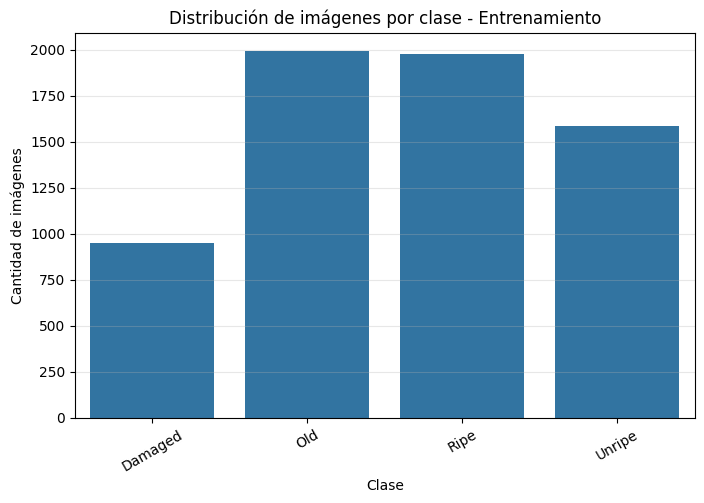

In [ ]:
# ==========================================
# ETAPA 2.4 - GRAFICAR DISTRIBUCIÓN DE CLASES
# ==========================================

plt.figure(figsize=(8, 5))
sns.barplot(data=df_train, x="clase", y="cantidad")
plt.title("Distribución de imágenes por clase - Entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
# ==========================================
# ETAPA 2.5 - CARGAR DATASETS CON KERAS
# ==========================================

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds_completo = keras.utils.image_dataset_from_directory(
    VAL_PATH,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Clases detectadas:")
print(class_names)

print("\nNúmero de clases:", NUM_CLASSES)

Found 6500 files belonging to 4 classes.
Found 724 files belonging to 4 classes.
Clases detectadas:
['Damaged', 'Old', 'Ripe', 'Unripe']

Número de clases: 4


In [ ]:
# ==========================================
# ETAPA 2.6 - CREAR CONJUNTO DE VALIDACIÓN Y PRUEBA
# ==========================================

if os.path.exists(TEST_PATH):
    test_ds = keras.utils.image_dataset_from_directory(
        TEST_PATH,
        labels="inferred",
        label_mode="int",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    val_ds = val_ds_completo

else:
    # Se divide la validación en dos partes:
    # 50% para validación y 50% para prueba.
    total_batches_val = tf.data.experimental.cardinality(val_ds_completo).numpy()

    test_batches = max(1, total_batches_val // 2)

    test_ds = val_ds_completo.take(test_batches)
    val_ds = val_ds_completo.skip(test_batches)

    print("La carpeta test no existe.")
    print("Batches totales de validación original:", total_batches_val)
    print("Batches usados para test:", test_batches)
    print("Batches usados para validación:", total_batches_val - test_batches)

print("Conjunto de validación y prueba preparados.")

La carpeta test no existe.
Batches totales de validación original: 23
Batches usados para test: 11
Batches usados para validación: 12
Conjunto de validación y prueba preparados.


In [ ]:
# ==========================================
# ETAPA 2.7 - OPTIMIZAR CARGA DE DATOS
# ==========================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Pipeline optimizado con cache y prefetch.")

Pipeline optimizado con cache y prefetch.


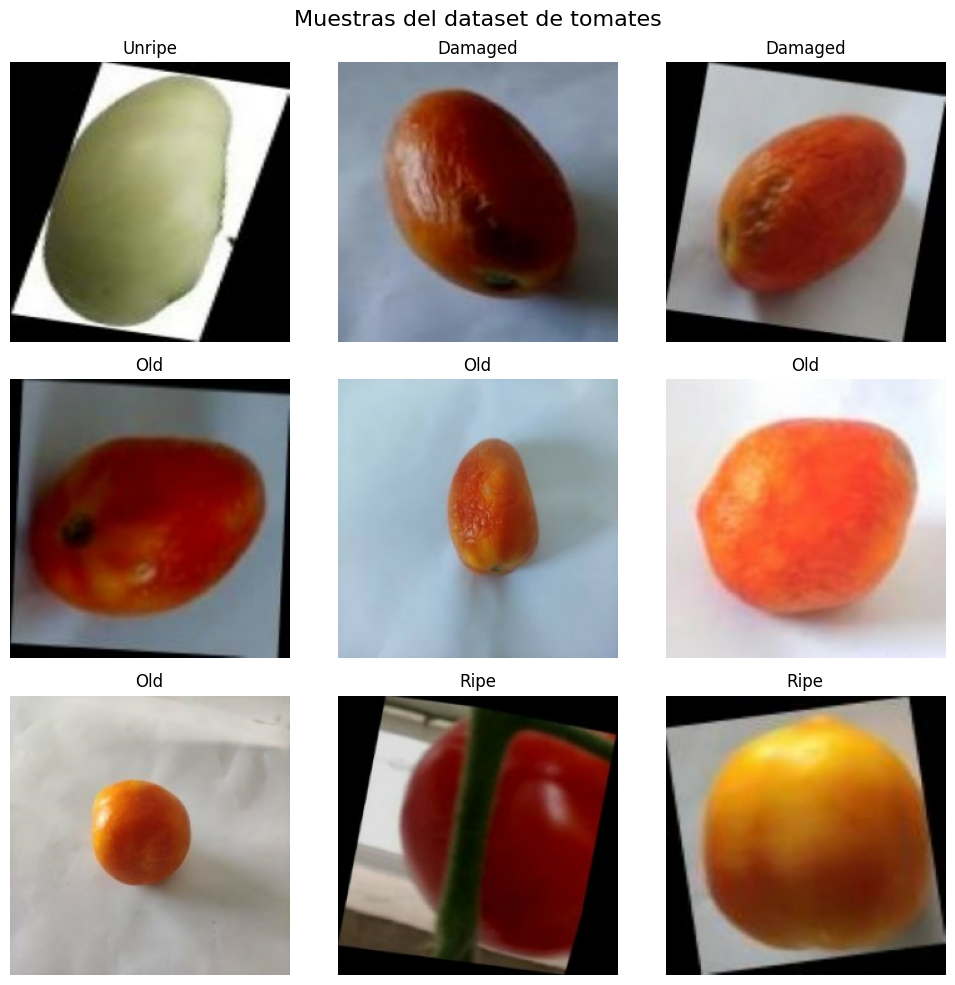

In [ ]:
# ==========================================
# ETAPA 2.8 - VISUALIZAR IMÁGENES DEL DATASET
# ==========================================

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.suptitle("Muestras del dataset de tomates", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# ETAPA 2.9 - CALCULAR PESOS DE CLASE
# ==========================================

conteos = []

for clase in class_names:
    ruta_clase = os.path.join(TRAIN_PATH, clase)
    cantidad = len([
        archivo for archivo in os.listdir(ruta_clase)
        if archivo.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif"))
    ])
    conteos.append(cantidad)

total = sum(conteos)

class_weight = {
    i: total / (NUM_CLASSES * conteos[i])
    for i in range(NUM_CLASSES)
}

print("Conteo por clase:")
for clase, cantidad in zip(class_names, conteos):
    print(clase, ":", cantidad)

print("\nPesos de clase:")
print(class_weight)

Conteo por clase:
Damaged : 949
Old : 1992
Ripe : 1975
Unripe : 1584

Pesos de clase:
{0: 1.7123287671232876, 1: 0.8157630522088354, 2: 0.8227848101265823, 3: 1.0258838383838385}


In [ ]:
# ==========================================
# ETAPA 3.1 - DATA AUGMENTATION
# ==========================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
], name="data_augmentation")

print("Capas de aumento de datos creadas correctamente.")

Capas de aumento de datos creadas correctamente.


In [ ]:
# ==========================================
# ETAPA 4.1 - CONSTRUIR MODELO VGG16
# ==========================================

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = data_augmentation(inputs)

# Preprocesamiento oficial de VGG16.
# No usamos rescale=1./255 porque VGG16 requiere su propio preprocess_input.
x = preprocess_input(x)

x = base_model(x, training=False)

# GlobalAveragePooling reduce parámetros y ayuda a evitar sobreajuste.
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="VGG16_Tomatoes_Classifier")

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_Tomatoes_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      1,028 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,848,068 (56.64 MB)

 Trainable params: 132,868 (519.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [ ]:
# ==========================================
# ETAPA 4.2 - COMPILAR MODELO
# ==========================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

print("Modelo compilado correctamente.")

Modelo compilado correctamente.


In [ ]:
# ==========================================
# ETAPA 4.3 - CALLBACKS
# ==========================================

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "mejor_modelo_vgg16_tomates.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.CSVLogger(
        "historial_entrenamiento_vgg16.csv"
    )
]

print("Callbacks configurados correctamente.")

Callbacks configurados correctamente.


In [ ]:
# ==========================================
# ETAPA 5.1 - ENTRENAMIENTO INICIAL
# ==========================================

inicio = time.time()

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

fin = time.time()

tiempo_entrenamiento_inicial = fin - inicio

print("Tiempo de entrenamiento inicial:", round(tiempo_entrenamiento_inicial / 60, 2), "minutos")

Epoch 1/25
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5102 - loss: 1.3946
Epoch 1: val_accuracy improved from None to 0.86290, saving model to mejor_modelo_vgg16_tomates.keras

Epoch 1: finished saving model to mejor_modelo_vgg16_tomates.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 44s 152ms/step - accuracy: 0.6263 - loss: 1.0392 - val_accuracy: 0.8629 - val_loss: 0.3894 - learning_rate: 1.0000e-04
Epoch 2/25
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7909 - loss: 0.5748
Epoch 2: val_accuracy improved from 0.86290 to 0.88441, saving model to mejor_modelo_vgg16_tomates.keras

Epoch 2: finished saving model to mejor_modelo_vgg16_tomates.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.8054 - loss: 0.5323 - val_accuracy: 0.8844 - val_loss: 0.3055 - learning_rate: 1.0000e-04
Epoch 3/25
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8411 - loss: 0.4656
Epoch 3: val_accuracy improved from 0.88441 to 0.90860, saving model to mejor_modelo_vgg16_tomate

In [ ]:
# ==========================================
# ETAPA 5.2 - CONFIGURAR FINE-TUNING
# ==========================================

base_model.trainable = True

# Solo se descongela el bloque 5 de VGG16.
# Esto permite ajustar características profundas sin modificar toda la red.
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINE),
    loss="sparse_categorical_crossentropy",
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

print("Fine-tuning configurado correctamente.")
print("Capas entrenables después del fine-tuning:")

for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Fine-tuning configurado correctamente.
Capas entrenables después del fine-tuning:
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [ ]:
# ==========================================
# ETAPA 5.3 - ENTRENAMIENTO CON FINE-TUNING
# ==========================================

inicio = time.time()

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

fin = time.time()

tiempo_fine_tuning = fin - inicio

print("Tiempo de fine-tuning:", round(tiempo_fine_tuning / 60, 2), "minutos")

Epoch 1/15
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9220 - loss: 0.2241
Epoch 1: val_accuracy improved from 0.93011 to 0.95161, saving model to mejor_modelo_vgg16_tomates.keras

Epoch 1: finished saving model to mejor_modelo_vgg16_tomates.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 39s 176ms/step - accuracy: 0.9269 - loss: 0.2030 - val_accuracy: 0.9516 - val_loss: 0.1279 - learning_rate: 1.0000e-05
Epoch 2/15
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9444 - loss: 0.1803
Epoch 2: val_accuracy improved from 0.95161 to 0.95699, saving model to mejor_modelo_vgg16_tomates.keras

Epoch 2: finished saving model to mejor_modelo_vgg16_tomates.keras
204/204 ━━━━━━━━━━━━━━━━━━━━ 36s 178ms/step - accuracy: 0.9437 - loss: 0.1701 - val_accuracy: 0.9570 - val_loss: 0.1221 - learning_rate: 1.0000e-05
Epoch 3/15
203/204 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9565 - loss: 0.1330
Epoch 3: val_accuracy improved from 0.95699 to 0.97849, saving model to mejor_modelo_vgg16_tom

In [ ]:
# ==========================================
# ETAPA 5.4 - UNIR HISTORIALES DE ENTRENAMIENTO
# ==========================================

def unir_historiales(history1, history2=None):
    historial = {}

    # Guardar historial de la primera fase
    for key in history1.history.keys():
        historial[key] = history1.history[key]

    # Si existe una segunda fase, unirla
    if history2 is not None:
        for key in history2.history.keys():
            if key in historial:
                historial[key] = historial[key] + history2.history[key]
            else:
                historial[key] = history2.history[key]

    return historial


# Verificar si existe history_fine
if "history_fine" in globals():
    history_total = unir_historiales(history_head, history_fine)
    print("Historial unido correctamente: entrenamiento inicial + fine-tuning.")
else:
    history_total = unir_historiales(history_head)
    print("Solo se encontró el historial del entrenamiento inicial.")
    print("No se encontró history_fine porque aún no se ha ejecutado el fine-tuning.")

print("Métricas disponibles:")
print(history_total.keys())

Historial unido correctamente: entrenamiento inicial + fine-tuning.
Métricas disponibles:
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


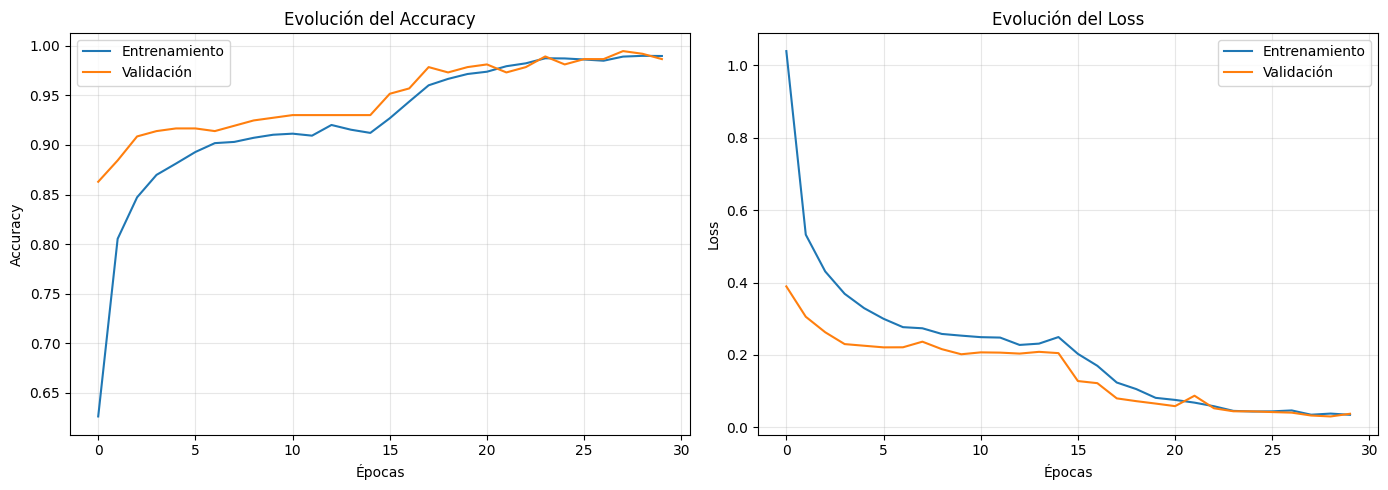

In [ ]:
# ==========================================
# ETAPA 6.1 - GRAFICAR ACCURACY Y LOSS
# ==========================================

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_total["accuracy"], label="Entrenamiento")
plt.plot(history_total["val_accuracy"], label="Validación")
plt.title("Evolución del Accuracy")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_total["loss"], label="Entrenamiento")
plt.plot(history_total["val_loss"], label="Validación")
plt.title("Evolución del Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# ETAPA 6.2 - EVALUAR MODELO EN TEST
# ==========================================

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("Resultados en conjunto de prueba")
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.9830 - loss: 0.0491
Resultados en conjunto de prueba
Test Loss: 0.0491
Test Accuracy: 0.983


In [ ]:
# ==========================================
# ETAPA 6.3 - OBTENER PREDICCIONES
# ==========================================

def obtener_predicciones(modelo, dataset):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probabilidades = modelo.predict(images, verbose=0)

        predicciones = np.argmax(probabilidades, axis=1)
        confianza = np.max(probabilidades, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicciones)
        y_prob.extend(confianza)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

y_true, y_pred, y_prob = obtener_predicciones(model, test_ds)

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

metricas = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1-score Macro",
        "Precision Weighted",
        "Recall Weighted",
        "F1-score Weighted"
    ],
    "Valor": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted
    ]
})

display(metricas)

print("Reporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

,Métrica,Valor
0,Accuracy,0.982955
1,Precision Macro,0.976829
2,Recall Macro,0.984036
3,F1-score Macro,0.980154
4,Precision Weighted,0.983508
5,Recall Weighted,0.982955
6,F1-score Weighted,0.983011


Reporte de clasificación:
              precision    recall  f1-score   support

     Damaged       0.93      0.98      0.95        51
         Old       0.99      0.96      0.97       113
        Ripe       0.99      1.00      1.00       105
      Unripe       1.00      1.00      1.00        83

    accuracy                           0.98       352
   macro avg       0.98      0.98      0.98       352
weighted avg       0.98      0.98      0.98       352



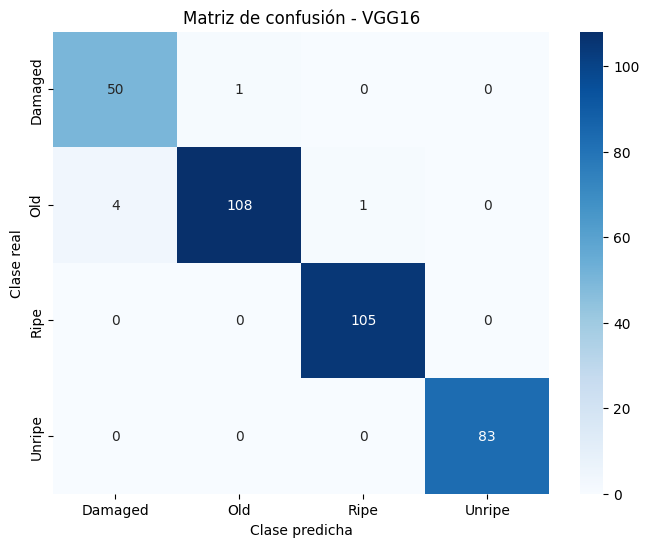

In [ ]:
# ==========================================
# ETAPA 6.4 - MATRIZ DE CONFUSIÓN
# ==========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de confusión - VGG16")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

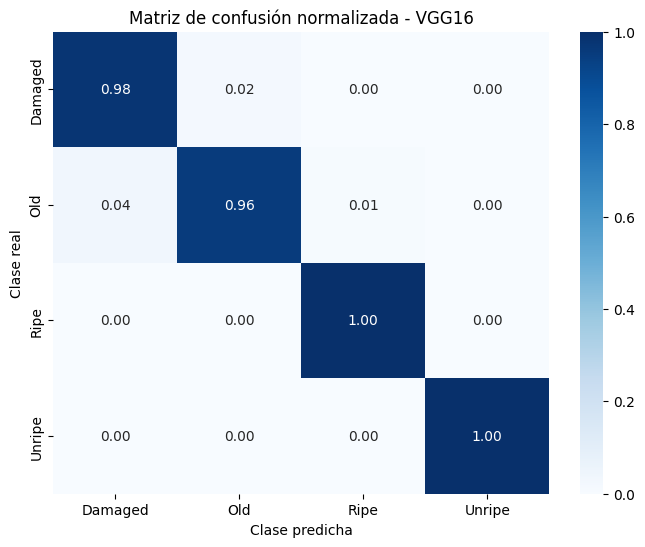

In [ ]:
# ==========================================
# ETAPA 6.5 - MATRIZ DE CONFUSIÓN NORMALIZADA
# ==========================================

cm_normalizada = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalizada,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de confusión normalizada - VGG16")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

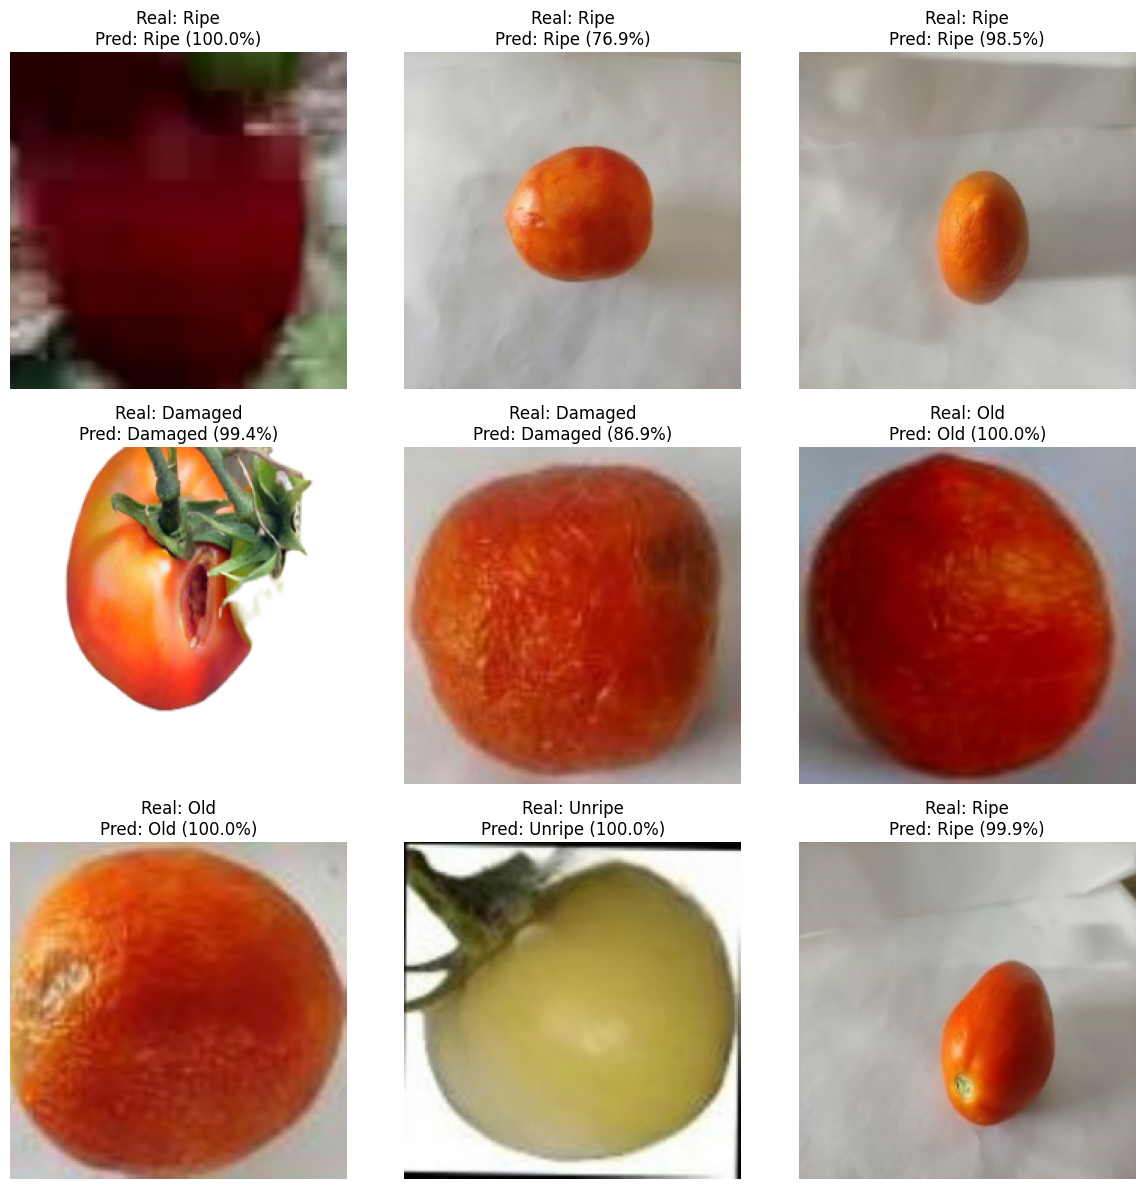

In [ ]:
# ==========================================
# ETAPA 6.6 - VISUALIZAR PREDICCIONES DEL MODELO
# ==========================================

plt.figure(figsize=(12, 12))

for images, labels in test_ds.take(1):
    probabilidades = model.predict(images, verbose=0)
    predicciones = np.argmax(probabilidades, axis=1)
    confianza = np.max(probabilidades, axis=1)

    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        real = class_names[int(labels[i])]
        predicha = class_names[int(predicciones[i])]
        conf = confianza[i] * 100

        titulo = f"Real: {real}\nPred: {predicha} ({conf:.1f}%)"

        plt.title(titulo)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# ETAPA 7.1 - GUARDAR MODELO Y CLASES
# ==========================================

model.save("modelo_final_vgg16_tomates.keras")

with open("clases_tomates.txt", "w") as f:
    for clase in class_names:
        f.write(clase + "\n")

metricas.to_csv("metricas_vgg16_tomates.csv", index=False)

print("Modelo guardado como: modelo_final_vgg16_tomates.keras")
print("Clases guardadas como: clases_tomates.txt")
print("Métricas guardadas como: metricas_vgg16_tomates.csv")

Modelo guardado como: modelo_final_vgg16_tomates.keras
Clases guardadas como: clases_tomates.txt
Métricas guardadas como: metricas_vgg16_tomates.csv


Saving images (1).jpg to images (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


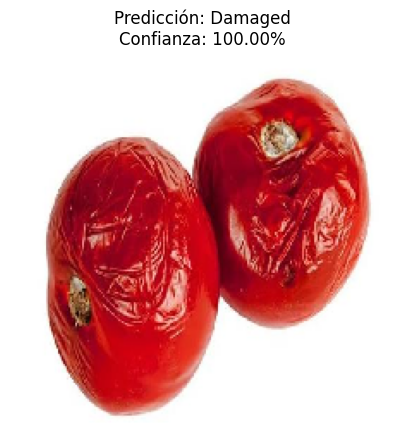

Archivo: images (1).jpg
Clase predicha: Damaged
Confianza: 100.0 %


In [ ]:
# ==========================================
# ETAPA 7.2 - PROBAR CON UNA IMAGEN INDIVIDUAL
# ==========================================

from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

uploaded = files.upload()

for nombre_archivo in uploaded.keys():
    img = load_img(nombre_archivo, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array_expandida = np.expand_dims(img_array, axis=0)

    prediccion = model.predict(img_array_expandida)
    clase_predicha = class_names[np.argmax(prediccion)]
    confianza = np.max(prediccion) * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicción: {clase_predicha}\nConfianza: {confianza:.2f}%")
    plt.show()

    print("Archivo:", nombre_archivo)
    print("Clase predicha:", clase_predicha)
    print("Confianza:", round(confianza, 2), "%")